# 12 · Random Forest + Kriging

Template para `RegressionKrigingModel`, separando claramente la parte no lineal del bosque y el ajuste espacial sobre residuos.

## Hipótesis del modelo

- El Random Forest captura relaciones no lineales y umbrales.
- El kriging sobre residuos agrega estructura espacial que el bosque no explica por sí solo.
- La interpretación puede combinar importancia global de features con mapas de residuo antes y después del kriging.

In [26]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.rfrkModel import RegressionKrigingModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import *

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "12_rf_kriging"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y configuración

In [27]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)



target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m"
]



In [28]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [29]:
rf_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 3,
    "max_features": "log2",
}

kriging_params = {
    "n_closest_points": 7,
    "variogram_model": "linear",
    "pseudo_inv": True,
    "pseudo_inv_type": "pinvh",
}

model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params)
model.fit(X_train, y_train, coords_train)
model


Finished learning regression model
Finished kriging residuals


## Tuning tentativo

Acá podés barrer hiperparámetros del bosque y del kriging, o hacer primero tuning del RF y después del componente espacial.

In [30]:

model.tune_hyperparameters(X_test, y_test.values.ravel(), coords_test)
best_config = {"RegressionKriging_params": rf_params, "kriging_params": kriging_params, "selected_k": getattr(model, "kriging_params_", {}).get("n_closest_points", None)}
best_config


Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals


{'RegressionKriging_params': {'n_estimators': 200,
  'max_depth': None,
  'min_samples_leaf': 1,
  'max_features': 'sqrt'},
 'kriging_params': {'n_closest_points': 5,
  'variogram_model': 'linear',
  'pseudo_inv': True,
  'pseudo_inv_type': 'pinvh'},
 'selected_k': None}

## Evaluación global

In [31]:
y_pred_log = model.predict(
    X_val,
    coords_val
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_val)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 62549.37557074645,
 'mae': 30786.35381405108,
 'r2': 0.7554289973794073,
 'bias': 9793.286555987655,
 'median_abs_error': 15235.786683861224,
 'mape': 18.374065525982903}

## Visualización


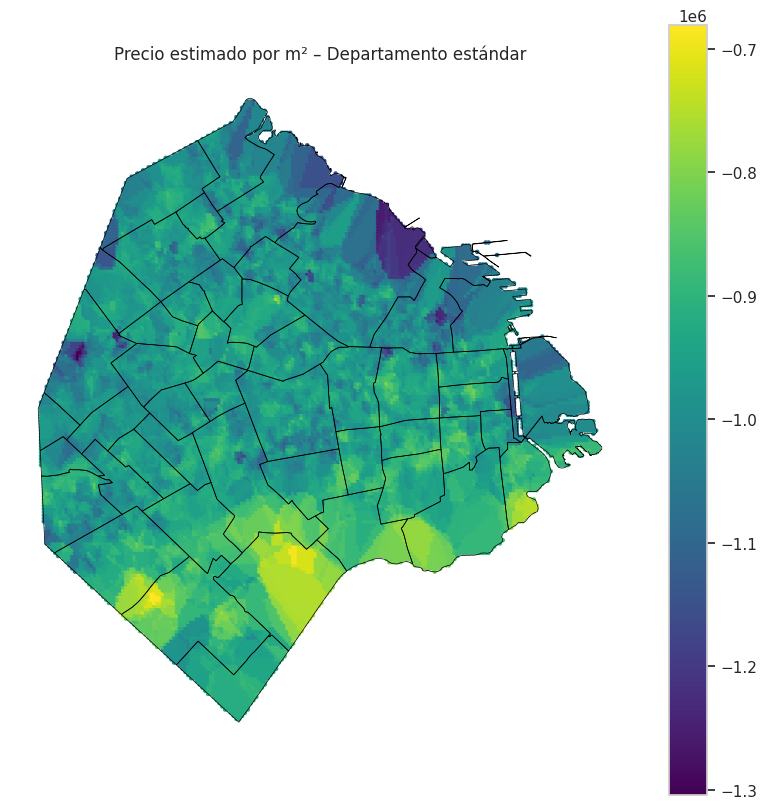

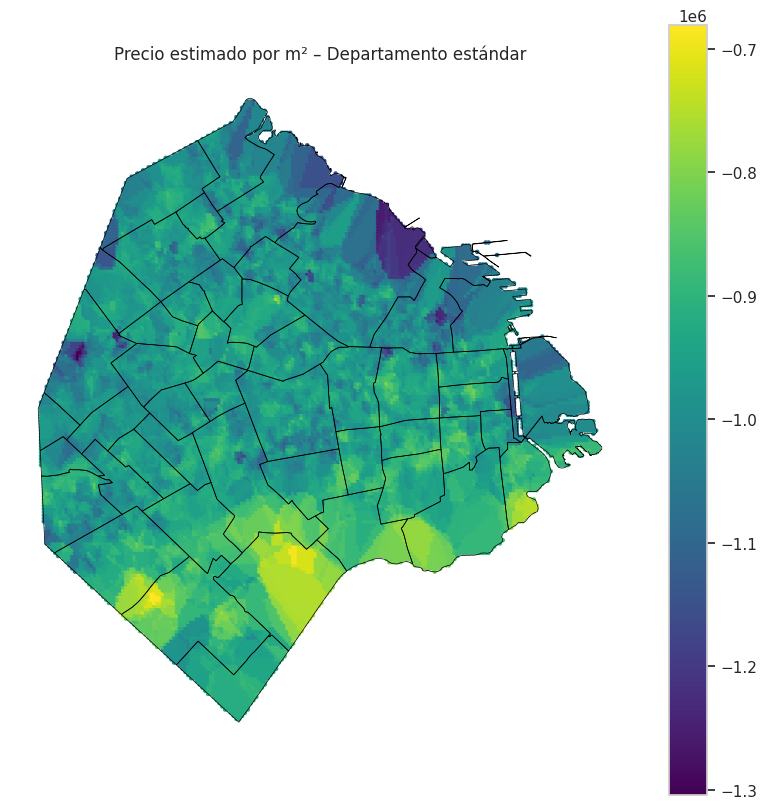

In [32]:
barrios_path = PROJECT_ROOT / 'GeoData' / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación del Random Forest

In [33]:
# feature_importance = pd.DataFrame({
#     "feature": feature_cols,
#     "importance": model.feature_importances_(),
# }).sort_values("importance", ascending=False)
# feature_importance

## Residuo del bosque vs residuo final

Si querés entender el aporte del kriging, compará explícitamente el error del RF puro contra el error final del modelo combinado.

In [34]:
# rf_only_pred = model.rf_.predict(X_test)
# comparison = pd.DataFrame({
#     "y_true": y_test,
#     "rf_pred": np.asarray(rf_only_pred).reshape(-1),
#     "rk_pred": np.asarray(y_pred).reshape(-1),
# })
# comparison["rf_residual"] = comparison["y_true"] - comparison["rf_pred"]
# comparison["rk_residual"] = comparison["y_true"] - comparison["rk_pred"]
# comparison.head()

## Export

In [35]:
# test_export = test_df[[target_col] + coord_cols].copy()
# test_export = test_export.rename(columns={target_col: "y_true"})
# test_export["y_pred"] = np.asarray(y_pred).reshape(-1)
# test_export["residual"] = test_export["y_true"] - test_export["y_pred"]
# test_export["rf_only_pred"] = np.asarray(rf_only_pred).reshape(-1)
# test_export["split"] = "test"
# test_export.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False)
# feature_importance.to_parquet(OUTPUT_DIR / "interpretability.parquet", index=False)
# run_config = {"rf_params": rf_params, "kriging_params": kriging_params}
# (OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
# (OUTPUT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2, ensure_ascii=False))

Oportunity detector?

In [ ]:
from ml_core.outlierAnalysis.strategies import *
from ml_core.outlierAnalysis.spatialOutlierDetector import *
import os 
from libpysal.weights import Kernel
STRATEGIES = {
    "negative": NegativeResidualsStrategy(),
    "ztest": ZTestStrategy(),
    "quantile": QuantileStrategy(),
    "lisa": LISAStrategy()
}
def detect_model_outliers(
    *,
    model,
    residuals,
    gdf,
    coords,
    output_dir,
    methods=None,
    params_for_methods=None,
    k_neighbors=15,
    **legacy_params_for_methods
):

    os.makedirs(output_dir, exist_ok=True)

    params_for_methods = params_for_methods or {}
    if legacy_params_for_methods:
        params_for_methods = {**params_for_methods, **legacy_params_for_methods}

    if methods is None:
        methods = ["negative", "ztest", "quantile", "lisa"]

    model_name = model.__class__.__name__
    res = residuals
    coords = model.coords if hasattr(model, "coords") else coords

    detector = SpatialOutlierDetector()

    results = {}

    w = None
    if any(m in methods for m in ["ztest", "lisa"]):

        w = Kernel(
            coords,
            k=k_neighbors,
            function="gaussian",
            fixed=False
        )

    for method in methods:

        strategy = STRATEGIES[method]
        params_for_method = params_for_methods.get(method, {})

        result = strategy.run(
            res=res,
            gdf=gdf,
            coords=coords,
            detector=detector,
            w=w,
            params_for_method=params_for_method,
            output_dir=output_dir,
            model_name=model_name
        )

        results[method] = result

    return results

from sklearn.model_selection import KFold
import numpy as np
import pandas as pd


def detect_outliers_oof(
    *,
    model,
    X,
    y,
    gdf,
    coords,
    output_dir,
    n_splits=5,
    methods=None,
    params_for_methods=None,
    k_neighbors=15,
):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    all_results = []
    all_residuals = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

        print(f"\nFold {fold+1}/{n_splits}")

        X_train = X.iloc[train_idx]
        X_val   = X.iloc[val_idx]
    
        y_train = y.iloc[train_idx]
        y_val   = y.iloc[val_idx]

        gdf_val_fold = gdf.iloc[val_idx]
        coords_train = coords[train_idx]
        coords_val   = coords[val_idx]

        # entrenar
        model.fit(
            X_train,
            y_train,
            coords_train
        )

        # predecir
        y_pred = model.predict(
            X_val,
            coords_val
        )

        residuals = y_val.values - y_pred

        all_residuals[val_idx] = residuals

        # detectar outliers SOLO en val
        fold_output_dir = output_dir / f"fold_{fold}"

        results = detect_model_outliers(
            model=model,
            residuals=residuals,
            gdf=gdf_val_fold,
            coords=coords_val,
            output_dir=fold_output_dir,
            methods=methods,
            params_for_methods=params_for_methods,
            k_neighbors=k_neighbors
        )

        all_results.append(results)

    return all_results, all_residuals

DATA_PATH = PROJECT_ROOT / "data" / "processed"

all_raw = pd.read_csv(DATA_PATH / "arg_venta_data_processed.csv")
gdf_all = gpd.GeoDataFrame(
    all_raw,
    geometry=gpd.points_from_xy(
        all_raw["longitud"],
        all_raw["latitud"]
    ),
    crs="EPSG:4326"
)

X_all = gdf_all[feature_cols]
y_all = gdf_all[target_col]
coords_all = gdf_all[coord_cols].to_numpy()


results, residuals_oof = detect_outliers_oof(

    model=model,

    X=X_all,
    y=y_all,

    gdf=gdf_all,
    coords=coords_all,

    output_dir=OUTPUT_DIR / "outliers_oof",

    methods=["negative", "ztest", "quantile", "lisa"],

    params_for_methods={
        "ztest": {"alpha": 0.05},
        "quantile": {
            "lower_quantile": 0.25,
            "upper_quantile": 0.75
        },
        "lisa": {"alpha": 0.05}
    },

    k_neighbors=15,
    n_splits=5
)


Fold 1/5
Finished learning regression model
Finished kriging residuals


TypeError: RegressionKrigingModel.predict() missing 1 required positional argument: 'coords'